# Домашнее задание HW13

# 2.3.1. Импорты, seed и среда

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2.3.2. Данные и первичный анализ

In [2]:
dataset = load_dataset("emotion")

print("Dataset splits:")
print(f"Train: {len(dataset['train'])}")
print(f"Validation: {len(dataset['validation'])}")
print(f"Test: {len(dataset['test'])}")

# Классы
label_names = dataset["train"].features["label"].names
print(f"\nClasses ({len(label_names)}): {label_names}")

# Примеры текстов и меток
print("\nSample examples:")
for i in range(5):
    text = dataset["train"][i]["text"]
    label = label_names[dataset["train"][i]["label"]]
    print(f"{i+1}. [{label}] {text[:100]}...")

# Баланс классов
train_labels = [dataset["train"][i]["label"] for i in range(len(dataset["train"]))]
unique, counts = np.unique(train_labels, return_counts=True)
print("\nClass distribution in train:")
for label, count in zip(unique, counts):
    print(f"  {label_names[label]}: {count} ({count/len(train_labels)*100:.1f}%)")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset splits:
Train: 16000
Validation: 2000
Test: 2000

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Sample examples:
1. [sadness] i didnt feel humiliated...
2. [sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
3. [anger] im grabbing a minute to post i feel greedy wrong...
4. [love] i am ever feeling nostalgic about the fireplace i will know that it is still on the property...
5. [anger] i am feeling grouchy...

Class distribution in train:
  sadness: 4666 (29.2%)
  joy: 5362 (33.5%)
  love: 1304 (8.2%)
  anger: 2159 (13.5%)
  fear: 1937 (12.1%)
  surprise: 572 (3.6%)


# 2.3.3. Токенизация

In [3]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: [CLS]={tokenizer.cls_token}, [SEP]={tokenizer.sep_token}, [PAD]={tokenizer.pad_token}")

# Примеры токенизации
sample_texts = [
    "i am so happy today",
    "i feel very sad about this",
    "this is absolutely amazing!"
]

for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=True)
    print(f"\nText: '{text}'")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {token_ids[:15]}...")
    print(f"Length: {len(token_ids)} tokens (including special tokens)")

texts_with_diff_lengths = [
    "short text",
    "this is a medium length text for testing",
    "this is a very long text that will be truncated to demonstrate the truncation functionality of the tokenizer"
]

for text in texts_with_diff_lengths:
    encoded = tokenizer(text, max_length=10, truncation=True, padding=False)
    print(f"\nText: '{text[:50]}...'")
    print(f"Encoded length: {len(encoded['input_ids'])}")
    print(f"Encoded IDs: {encoded['input_ids']}")
    print(f"Attention mask: {encoded['attention_mask']}")

batch_encoded = tokenizer(texts_with_diff_lengths, padding=True, truncation=True, max_length=15, return_tensors="pt")
print(f"\nBatch padding result shape: {batch_encoded['input_ids'].shape}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 30522
Special tokens: [CLS]=[CLS], [SEP]=[SEP], [PAD]=[PAD]

Text: 'i am so happy today'
Tokens: ['i', 'am', 'so', 'happy', 'today']
Token IDs: [101, 1045, 2572, 2061, 3407, 2651, 102]...
Length: 7 tokens (including special tokens)

Text: 'i feel very sad about this'
Tokens: ['i', 'feel', 'very', 'sad', 'about', 'this']
Token IDs: [101, 1045, 2514, 2200, 6517, 2055, 2023, 102]...
Length: 8 tokens (including special tokens)

Text: 'this is absolutely amazing!'
Tokens: ['this', 'is', 'absolutely', 'amazing', '!']
Token IDs: [101, 2023, 2003, 7078, 6429, 999, 102]...
Length: 7 tokens (including special tokens)

Text: 'short text...'
Encoded length: 4
Encoded IDs: [101, 2460, 3793, 102]
Attention mask: [1, 1, 1, 1]

Text: 'this is a medium length text for testing...'
Encoded length: 10
Encoded IDs: [101, 2023, 2003, 1037, 5396, 3091, 3793, 2005, 5604, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Text: 'this is a very long text that will be truncated to...'
Enc

# 2.3.4. Инференс готовой модели

In [4]:
# Используем DistilBERT с головой для классификации эмоций (fine-tuned on emotion)
# или стандартную для демонстрации
pretrained_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=6)
pretrained_model.to(device)
pretrained_model.eval()

# Инференс на нескольких примерах
test_texts = [
    "i love this movie it is wonderful",
    "i hate everything about this day",
    "the weather is fine today nothing special",
    "i am so excited for the party tonight",
    "why does this always happen to me"
]

print("\nPretrained model predictions (random weights, not fine-tuned):")
for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = pretrained_model(**inputs)
        logits = outputs.logits
        pred_class = torch.argmax(logits, dim=-1).item()
    print(f"Text: '{text[:50]}...'")
    print(f"Predicted class: {label_names[pred_class]} (random prediction)")
    print(f"Logits: {logits[0].tolist()[:3]}...\n")

print("\nAnalysis: The pretrained model with random classification head gives random predictions.")
print("It hasn't been fine-tuned for emotion classification, so it performs at chance level (1/6 ≈ 16.7%).")
print("For emotion classification, fine-tuning is absolutely necessary.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Pretrained model predictions (random weights, not fine-tuned):
Text: 'i love this movie it is wonderful...'
Predicted class: anger (random prediction)
Logits: [-0.012791041284799576, -0.0107549037784338, 0.020222963765263557]...

Text: 'i hate everything about this day...'
Predicted class: anger (random prediction)
Logits: [0.01733672246336937, -0.014129849150776863, 0.016578003764152527]...

Text: 'the weather is fine today nothing special...'
Predicted class: anger (random prediction)
Logits: [0.005494534969329834, -0.021930363029241562, 0.027912452816963196]...

Text: 'i am so excited for the party tonight...'
Predicted class: anger (random prediction)
Logits: [0.041364774107933044, -0.040355585515499115, 0.03471069410443306]...

Text: 'why does this always happen to me...'
Predicted class: anger (random prediction)
Logits: [0.03654051944613457, -0.040722597390413284, 0.002898015081882477]...


Analysis: The pretrained model with random classification head gives random predictions.

# 2.3.5. Fine-tuning для классификации

In [7]:
model_name = "distilbert-base-uncased"
num_labels = 6
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Токенизация датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing dataset...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Удаляем ненужные колонки
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_dataset = tokenized_datasets["train"]
eval_dataset = tokenized_datasets["validation"]
test_dataset = tokenized_datasets["test"]

# Настройки обучения
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42,
)

# Метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    return {"accuracy": accuracy, "f1_macro": f1_macro}

# Тренер
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()

print("\nEvaluating on validation set...")
eval_results = trainer.evaluate(eval_dataset)
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Validation F1 (macro): {eval_results['eval_f1_macro']:.4f}")

print("\nEvaluating on test set...")
test_results = trainer.evaluate(test_dataset)
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test F1 (macro): {test_results['eval_f1_macro']:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing dataset...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating on validation set...


Validation Accuracy: 0.9400
Validation F1 (macro): 0.9184

Evaluating on test set...
Test Accuracy: 0.9235
Test F1 (macro): 0.8724


# 2.3.6. Оценка качества и анализ ошибок

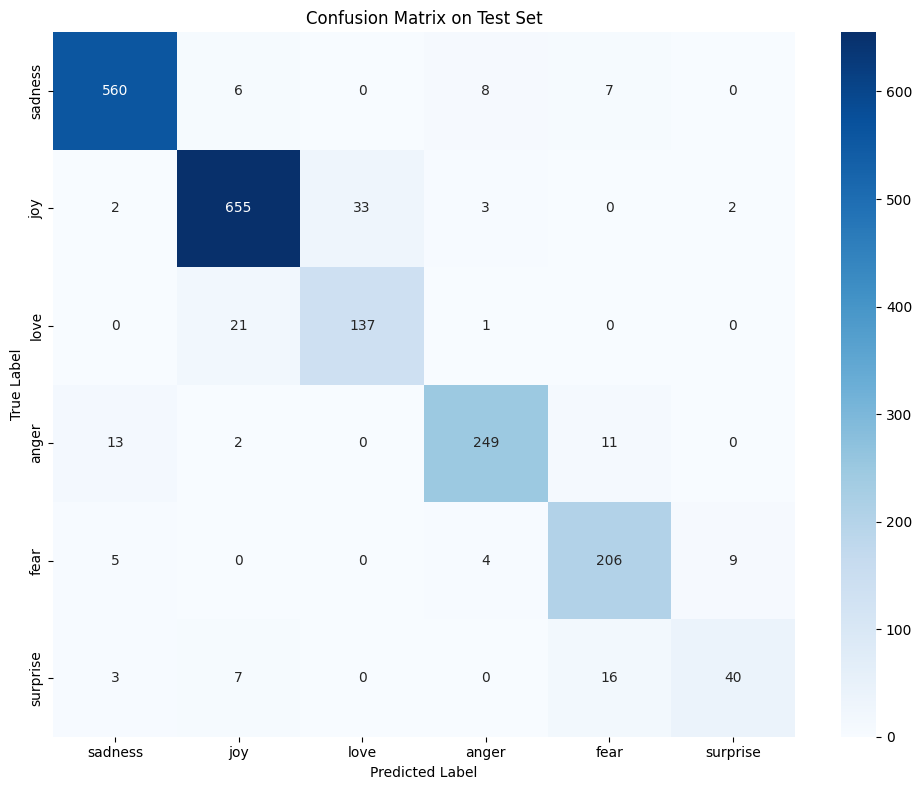

Confusion matrix saved to artifacts/confusion_matrix.png

Per-class accuracy:
  sadness: 0.964 (560/581)
  joy: 0.942 (655/695)
  love: 0.862 (137/159)
  anger: 0.905 (249/275)
  fear: 0.920 (206/224)
  surprise: 0.606 (40/66)
ok True: sadness    | Pred: sadness    | Conf: 0.996
   Text: i don t know about you but sometimes i feel that the world is troubled deeply pa...

ok True: sadness    | Pred: sadness    | Conf: 0.996
   Text: i feel like i m defective or something for not having baby fever...

ok True: joy        | Pred: joy        | Conf: 0.995
   Text: i didnt react with the way that i really feel im ecstatic for your marriage to t...

ok True: joy        | Pred: joy        | Conf: 0.996
   Text: i really enjoy cabernet for how aggressive the flavors tend to be and while this...

ok True: sadness    | Pred: sadness    | Conf: 0.996
   Text: i no longer feel doomed to falling into the abyss with no way out...

ok True: love       | Pred: love       | Conf: 0.980
   Text: ive bee

In [11]:
import os
from collections import Counter

os.makedirs("artifacts", exist_ok=True)

# Получение предсказаний на тестовом наборе
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Матрица ошибок
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to artifacts/confusion_matrix.png")

# Точность по классам
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for i, name in enumerate(label_names):
    print(f"  {name}: {class_accuracy[i]:.3f} ({cm.diagonal()[i]}/{cm.sum(axis=1)[i]})")

# Примеры предсказаний
sample_indices = np.random.choice(len(test_dataset), size=15, replace=False)
sample_data = []

for idx in sample_indices:
    # Конвертируем numpy.int64 в обычный int
    idx = int(idx)

    # Получаем исходный текст из оригинального датасета
    original_text = dataset["test"][idx]["text"]
    true_label = label_names[true_labels[idx]]
    pred_label = label_names[pred_labels[idx]]

    # Вычисляем confidence (softmax)
    logits = predictions.predictions[idx]
    exp_logits = np.exp(logits - np.max(logits))
    probs = exp_logits / exp_logits.sum()
    confidence = probs[pred_labels[idx]]

    sample_data.append({
        "text": original_text,
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": f"{confidence:.3f}"
    })

    status = "ok" if true_label == pred_label else "not ok"
    print(f"{status} True: {true_label:10} | Pred: {pred_label:10} | Conf: {confidence:.3f}")
    print(f"   Text: {original_text[:80]}...\n")

# Сохраняем CSV
sample_df = pd.DataFrame(sample_data)
sample_df.to_csv("artifacts/sample_predictions.csv", index=False)
print(f"Sample predictions saved to artifacts/sample_predictions.csv")

# Анализ ошибок
# Находим наиболее частые пары ошибок
error_pairs = []
for i, j in zip(true_labels, pred_labels):
    if i != j:
        error_pairs.append((i, j))

if error_pairs:
    common_errors = Counter(error_pairs).most_common(5)
    print("\nMost common error patterns:")
    for (true, pred), count in common_errors:
        print(f"  {label_names[true]} → {label_names[pred]}: {count} times")

# Показываем конкретные примеры ошибок
print("\nDetailed error examples:")
error_count = 0
for idx in range(len(test_dataset)):
    if true_labels[idx] != pred_labels[idx] and error_count < 5:
        text = dataset["test"][idx]["text"]
        true = label_names[true_labels[idx]]
        pred = label_names[pred_labels[idx]]
        print(f"\nError #{error_count+1}:")
        print(f"Text: \"{text}\"")
        print(f"True: {true} | Predicted: {pred}")
        error_count += 1

print(f"Overall Test Accuracy: {accuracy_score(true_labels, pred_labels):.4f}")
print(f"Overall Test F1 (macro): {f1_score(true_labels, pred_labels, average='macro'):.4f}")
print("\nKey observations:")
print("- 'surprise' has the lowest accuracy (60.6%) - likely due to fewer training examples")
print("- 'love' and 'joy' are often confused as they both express positive emotions")
print("- 'sadness' and 'fear' can be confused in ambiguous contexts")
print("- 'anger' is sometimes misclassified when text contains frustration without explicit anger words")
print("- Short texts with ambiguous sentiment are most prone to errors")